Simulation Start (N=1000)


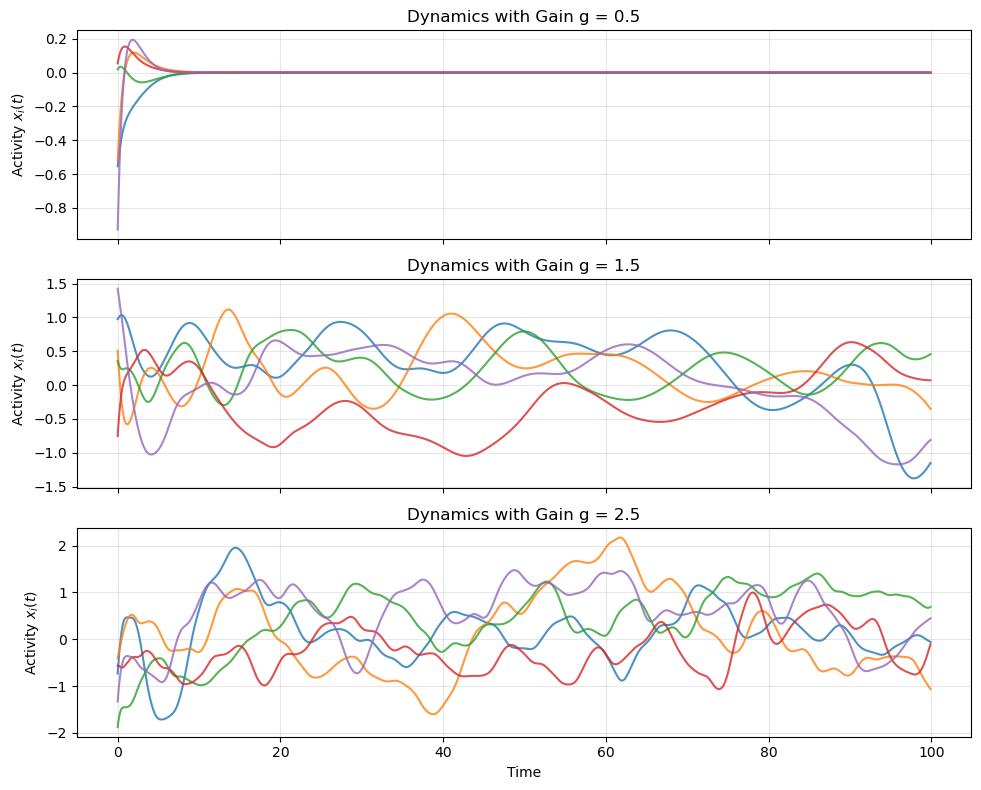

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_rnn_simulation():
    # --- パラメータ設定 ---
    N = 1000            # ニューロン数 (10-1000)
    dt = 0.1            # 時間刻み
    steps = 1000        # シミュレーションステップ数
    time = np.arange(steps) * dt
    
    # gの値をいくつか設定して比較する
    # 理論的には g=1 が転移点。それより小さい値と大きい値を用意。
    g_values = [0.5, 1.5, 2.5] 

    # --- 結合行列 J の生成 ---
    # 平均 0, 分散 1/N => 標準偏差 1/sqrt(N)
    J = np.random.normal(loc=0, scale=1/np.sqrt(N), size=(N, N))

    # プロットの準備
    fig, axes = plt.subplots(len(g_values), 1, figsize=(10, 8), sharex=True)
    if len(g_values) == 1: axes = [axes] # gが1つの場合の対応

    print(f"Simulation Start (N={N})")

    # --- 各 g についてシミュレーション実行 ---
    for idx, g in enumerate(g_values):
        # 初期状態 (ランダム)
        x = np.random.randn(N)
        
        # 記録用配列 (計算負荷軽減のため、代表的な数個のニューロンだけ記録)
        # ここでは最初の5個のニューロンの活動を記録します
        record_num = 5
        history = np.zeros((steps, record_num))
        
        # 時間発展 (オイラー法)
        # dx/dt = -x + sum(J * tanh(g*x))
        # x(t+dt) = x(t) + dt * (-x(t) + J @ tanh(g*x(t)))
        
        current_x = x
        for t in range(steps):
            history[t, :] = current_x[:record_num]
            
            # 非線形変換 phi(x) = tanh(g*x)
            phi = np.tanh(g * current_x)
            
            # 相互作用項
            interaction = J @ phi  # 行列ベクトル積
            
            # 更新
            dx = -current_x + interaction
            current_x = current_x + dt * dx

        # --- プロット ---
        ax = axes[idx]
        for i in range(record_num):
            ax.plot(time, history[:, i], alpha=0.8, label=f'Neuron {i+1}')
        
        ax.set_title(f'Dynamics with Gain g = {g}')
        ax.set_ylabel('Activity $x_i(t)$')
        ax.grid(True, alpha=0.3)
        if idx == len(g_values) - 1:
            ax.set_xlabel('Time')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_rnn_simulation()
